In [1]:
%matplotlib ipympl
%load_ext autoreload
%autoreload 2

In [2]:
%cd ../../

c:\Users\Matth\OneDrive\Documents\UMD\classes\junior year\Summer\research\R determination


In [3]:
import Util
import Spec1D
import Spec2D
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

C:\Users\Matth\AppData\Local\Temp\ipykernel_35360\1101667814.py:12: RuntimeWarning: invalid value encountered in sqrt
  view = np.sqrt(spec2D)#Sqrt makes it more clear to see the faint and bright lines at the same time


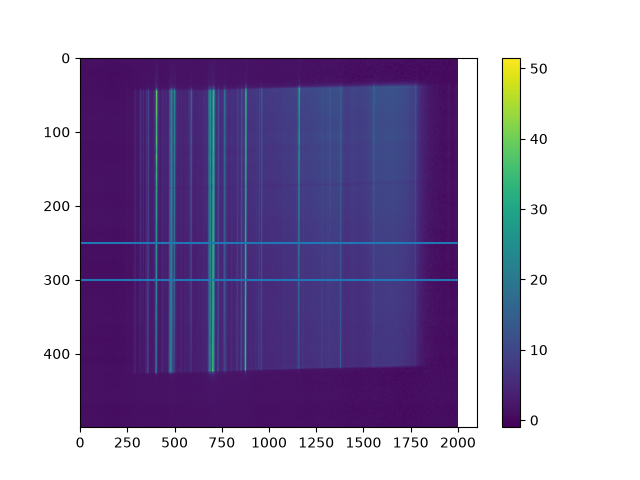

In [4]:


linePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\XeHgArKr_lines.dat"
lines =  Util.createLineList(linePath, mergedLines=["Kr"])

imagePath = "C:\\Users\\Matth\\OneDrive\\Documents\\UMD\\classes\\junior year\\Semester 2\\research\\TestArcCalib.HK.fits"
spec2D = fits.open(imagePath)[0].data
Spec2D.flipX(spec2D)

minY = 250
maxY = 300

fig, ax = plt.subplots()
view = np.sqrt(spec2D)#Sqrt makes it more clear to see the faint and bright lines at the same time
view[np.isnan(view)]=-1
img = ax.imshow(view, vmin=np.min(view), vmax=np.max(view)) 
fig.colorbar(img)
ax.hlines([minY, maxY], 0, 2000)
ax.set_aspect("auto")

spec = Spec1D.convert2Dto1D(spec2D, minY, maxY)
continuum = Spec1D.continuum(spec)
contSub = spec - continuum(np.arange(0, len(spec)))

plt.show()

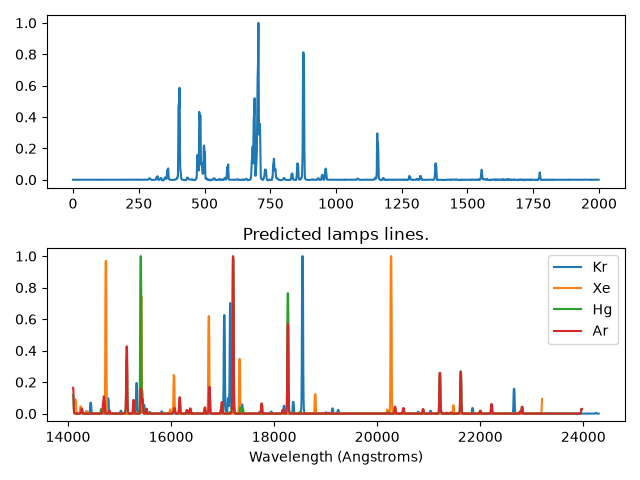

In [5]:
fig, ax = plt.subplots(2,1)
ax[0].plot(contSub/np.max(contSub))
XeLines = Util.simpleLineListToPypeIt("HK/arc.Xe.HK_identified_lines.curvefit_peaks.csv", ion="XeI", conversionFactorToAngstroms=10000, writePath="Xe_RIMAS_HK_lines.dat")
ArLines = Util.simpleLineListToPypeIt("HK/arc.Ar.HK_identified_lines.curvefit_peaks.csv", ion="ArI", conversionFactorToAngstroms=10000, writePath="Ar_RIMAS_HK_lines.dat")
HgLines = Util.simpleLineListToPypeIt("HK/arc.Hg.HK_identified_lines.curvefit_peaks.csv", ion="HgI", conversionFactorToAngstroms=10000, writePath="Hg_RIMAS_HK_lines.dat")
KrLines = Util.simpleLineListToPypeIt("HK/arc.Kr.HK_identified_lines.curvefit_peaks.csv", ion="KrI", conversionFactorToAngstroms=10000, writePath="Kr_RIMAS_HK_lines.dat")
XeModel = Spec1D.calcModel(XeLines, 2000, XeLines[0][0], 2000/(XeLines[-1][0]-XeLines[0][0]))
ArModel = Spec1D.calcModel(ArLines, 2000, ArLines[0][0], 2000/(XeLines[-1][0]-XeLines[0][0]))
HgModel = Spec1D.calcModel(HgLines, 2000, HgLines[0][0], 2000/(XeLines[-1][0]-XeLines[0][0]))
KrModel = Spec1D.calcModel(KrLines, 2000, KrLines[0][0], 2000/(XeLines[-1][0]-XeLines[0][0]))
model = KrModel
ax[1].plot(np.linspace(KrLines[0][0], KrLines[-1][0], 2000), model/np.max(model), label="Kr")
ax[1].plot(np.linspace(XeLines[0][0], XeLines[-1][0], 2000), XeModel/np.max(XeModel), label="Xe")
ax[1].plot(np.linspace(HgLines[0][0], HgLines[-1][0], 2000), HgModel/np.max(HgModel), label="Hg")
ax[1].plot(np.linspace(ArLines[0][0], ArLines[-1][0], 2000), ArModel/np.max(ArModel), label="Ar")
ax[1].legend()
ax[1].set_xlabel("Wavelength (Angstroms)")
ax[1].set_title("Predicted lamps lines.")
fig.tight_layout()

[[14108.15, 'KrI', 1, 256, 12620.0, 'Kr_lines.dat'], [14160.49, 'KrI', 1, 257, 11080.0, 'Kr_lines.dat'], [14345.17, 'KrI', 1, 258, 30140.0, 'Kr_lines.dat'], [14351.4, 'KrI', 1, 259, 30440.0, 'Kr_lines.dat'], [14406.22, 'KrI', 1, 260, 19820.0, 'Kr_lines.dat'], [14430.736, 'KrI', 1, 261, 202500.0, 'Kr_lines.dat'], [14472.81, 'KrI', 1, 262, 17300.0, 'Kr_lines.dat'], [14521.6, 'KrI', 1, 263, 11560.0, 'Kr_lines.dat'], [14719.57, 'KrI', 1, 264, 9319.0, 'Kr_lines.dat'], [14738.469, 'KrI', 1, 265, 214300.0, 'Kr_lines.dat'], [14766.72, 'KrI', 1, 266, 107000.0, 'Kr_lines.dat'], [14769.52, 'KrI', 1, 267, 101300.0, 'Kr_lines.dat'], [14965.98, 'KrI', 1, 268, 62840.0, 'Kr_lines.dat'], [14977.83, 'KrI', 1, 269, 17970.0, 'Kr_lines.dat'], [15009.44, 'KrI', 1, 270, 27930.0, 'Kr_lines.dat'], [15213.7, 'KrI', 1, 271, 32770.0, 'Kr_lines.dat'], [15243.787, 'KrI', 1, 272, 463400.0, 'Kr_lines.dat'], [15270.1, 'KrI', 1, 273, 7317.0, 'Kr_lines.dat'], [15330.67, 'KrI', 1, 274, 182600.0, 'Kr_lines.dat'], [15339.1

Text(0.5, 1.0, "Predicted Normalized Intensity from Joe's lines.")

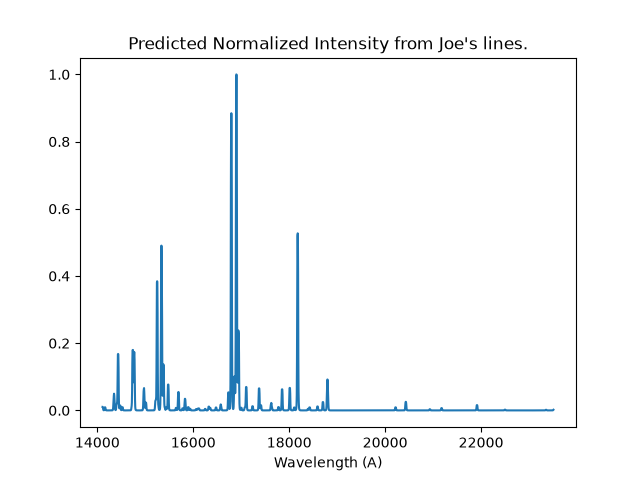

In [6]:
fig, ax = plt.subplots()
print(lines)
model = Spec1D.calcModel(lines, 2000, lines[0][0], 2000/(lines[-1][0]-lines[0][0]))
ax.plot(np.linspace(lines[0][0], lines[-1][0], 2000), model/np.max(model))
ax.set_xlabel("Wavelength (A)")
ax.set_title("Predicted Normalized Intensity from Joe's lines.")

Interactive Linear fit! Once this is cell is finish searching the parameter space (takes around 10 minutes on my machine with these resolution parameters), click the heatmap to see how the model changes with those parameters. The red x is located at the best solution that the machine found.

In [7]:
w, a = Spec1D.calcLinearFit(contSub, lines, 11000, 14000, 0.1, 0.3, resW=300, resS=300)
print(w, a)

KeyboardInterrupt: 

In [8]:
w=11684.684684684684 #Angstroms
a=0.13503503503503503 #Px/Angstrom

In [9]:
wavs = np.linspace(Spec1D.pixelToWav(0, w, a), Spec1D.pixelToWav(len(contSub)-1, w, a), len(contSub))
norm = contSub/np.max(contSub)
params = []
model = np.zeros_like(norm)

Interactive line analysis! To start editing the model lines, press the 'e' key on your keyboard to enable editing. Make sure you press the 'e' key a second time to disable editing if you want to resize or move around the spectrum!

Once you are in edit mode and can identify a single line that you would like to model, left click on the top of the line to fit it. If you misclick or the fit is bad, right click anywhere on the graph to remove it.

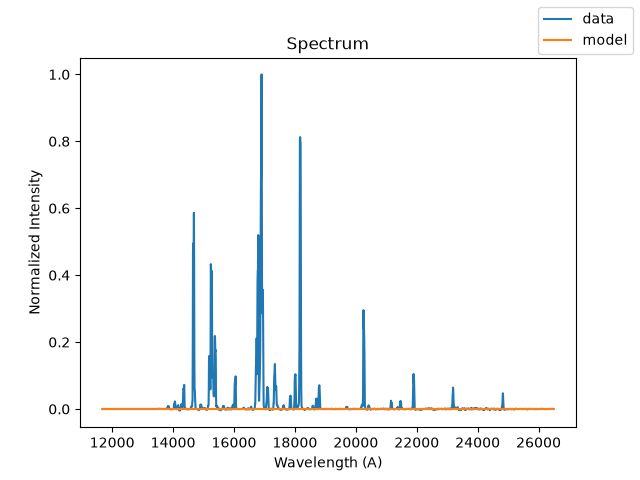

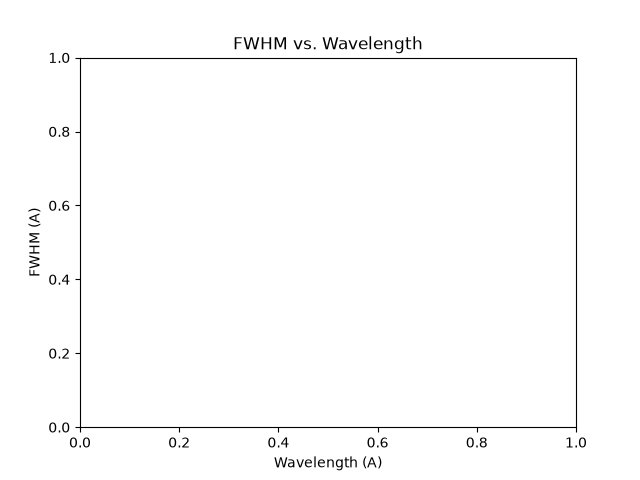

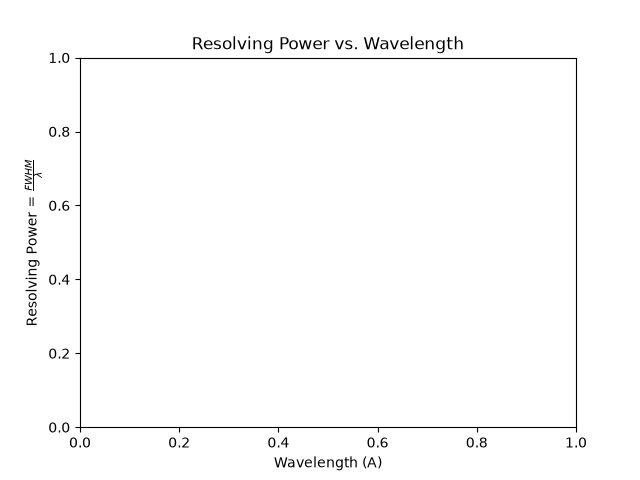

In [10]:
fig, ax = plt.subplots()
ax.set_title("Spectrum")
ax.set_xlabel("Wavelength (A)")
ax.set_ylabel("Normalized Intensity")
ax.plot(wavs,norm, label="data")
line, = ax.plot(wavs, model, label="model")
fig.legend()

FWFig, FWAx = plt.subplots()
FWAx.set_xlabel("Wavelength (A)")
FWAx.set_ylabel("FWHM (A)")
FWAx.set_title("FWHM vs. Wavelength")
RFig, RAx = plt.subplots()
RAx.set_xlabel("Wavelength (A)")
RAx.set_ylabel("Resolving Power = $\\frac{FWHM}{\\lambda}$")
RAx.set_title("Resolving Power vs. Wavelength")

def updateGraphs():
    line.set_ydata(model)
    fig.canvas.draw()
    fig.canvas.flush_events()

    tmp = np.array(params)
    FWHMs = Spec1D.LorentzWidthToFWHM(tmp[:,2])
    FWAx.clear()
    FWAx.plot(tmp[:,0], FWHMs, "o")
    FWAx.set_xlabel("Wavelength (A)")
    FWAx.set_ylabel("FWHM (A)")
    FWAx.set_title("FWHM vs. Wavelength")
    FWFig.canvas.draw()
    FWFig.canvas.flush_events()

    RAx.clear()
    RAx.plot(tmp[:,0], tmp[:,0]/FWHMs, "o")
    RAx.set_xlabel("Wavelength (A)")
    RAx.set_ylabel("Resolving Power = $\\frac{FWHM}{\\lambda}$")
    RAx.set_title("Resolving Power vs. Wavelength")
    RFig.canvas.draw()
    RFig.canvas.flush_events()

if len(params)>0:
    updateGraphs()

def onclick(event):
    global model
    if edit:
        if event.button == 1: #button 1 is left mouse button
            l = event.xdata
            index=Spec1D.wavToPixel(l, w, a)
            intensities=norm[index-9:index+9]
            wavSec = wavs[index-9:index+9]
            var, cov = curve_fit(Spec1D.LorentzLine, wavSec, intensities, (l, event.ydata, 20, 0, 2),bounds=([l-50,0,0,0,0],[l+50, 1,200,1e-5,np.inf]), sigma=np.sqrt(np.abs(intensities)), absolute_sigma=True)
            params.append(var)
            #params is center wavelength, amplitude, width, offset, and power
            model += Spec1D.LorentzLine(wavs, params[-1][0], params[-1][1], params[-1][2], 0, params[-1][4])

            #refresh the canvas
        if event.button == 3: #right mouse button
            model -= Spec1D.LorentzLine(wavs, params[-1][0], params[-1][1], params[-1][2], 0, params[-1][4])
            params.pop()
        
        updateGraphs()

edit = False
def onkey(event):
    global edit
    print(event.key)
    if event.key == "e":
        if edit:
            edit = False
        else:
            edit = True

cid = fig.canvas.mpl_connect('button_press_event', onclick)
cid = fig.canvas.mpl_connect('key_press_event', onkey)

In [22]:
tmp = np.array(params)
FWHMs = Spec1D.LorentzWidthToFWHM(tmp[:,2])
Rs = tmp[:,0]/FWHMs
print(Rs)
print(np.median(Rs))

[270.67988148 292.90275947 278.21594248 313.10665237 316.00241989
 297.44472605 349.96340027 394.27566864 354.83176863 320.61467307
 468.77129775 346.35238548 305.30922416 394.60714793 416.60467638
 426.36653435 442.48793134 365.20329008 437.62229451 428.13169458
 416.13276836 429.8620421  476.3612831  467.52771175 472.12577988
 488.55398637 490.70181831 611.86213377 946.29213168]
416.13276836132655
